<a href="https://colab.research.google.com/github/GopalKrishna-India/Geospatial/blob/master/SDM_with_RandomForest_in_R_example_En.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Practical Guide: Species Distribution Modeling (SDM) with Random Forest in R

Welcome! This notebook is a step-by-step guide for researchers who are beginning to work with **Species Distribution Modeling (SDM)**.

We will go through the complete workflow for building a spatial model: from preparing raw data to producing the final Habitat Suitability Map. We will use **Random Forest**, one of the most powerful and widely used machine-learning methods in modern ecology.

**Training example:** To make the workflow as clear as possible, we will use the classic dataset from the `dismo` package containing occurrence records for the **brown-throated sloth** (*Bradypus variegatus*) in South and Central America. We will train the algorithm to associate known occurrence coordinates with climatic factors such as temperature and precipitation, and then predict which additional, unsampled areas may be suitable for the species.

**What this pipeline includes:**

* **Environment setup:** How to run full R code inside Google Colab's Python environment using the `%%R` magic.
* **Data preparation:** Loading sloth occurrence points and extracting climatic predictors at those coordinates.
* **Background generation:** Creating pseudo-absence points required to train the algorithm.
* **Training and testing:** Splitting the data, configuring Random Forest, and analyzing variable importance.
* **Model evaluation:** Testing the model on unseen data, calculating AUC, and plotting the ROC curve.
* **Spatial prediction:** Projecting the model across a map and exporting the resulting raster.

> **💡 Note:** All code in this notebook is written in **R**. Special commands at the beginning of cells allow Google Colab to interpret R syntax without requiring RStudio on your computer. Run the cells in order.

## Step 1: Install the required libraries

In [ ]:
# Import Colab modules for clearing cell output and downloading files
from google.colab import output
from google.colab import files

# Colab is a Linux (Ubuntu) virtual machine.
# Commands beginning with an exclamation mark run directly in the Linux terminal.
# First, update the system package index; `-qq` suppresses most output.
!apt-get -qq update

# This is the MOST IMPORTANT line for geographers and ecologists.
# R packages such as raster, terra, and rgdal depend on system-level C++ libraries: GDAL, PROJ, and GEOS.
# Install base R and these spatial libraries.
!apt-get -qq install -y r-base libgdal-dev libproj-dev libgeos-dev libudunits2-dev

# rpy2 is the bridge between Python and R.
# It enables the `%%R` magic used in later cells.
# Recent Colab versions usually include it, so the installation line is commented out.
# Uncomment it if an error occurs.
# !pip install rpy2

# System package installation produces a large amount of technical output.
# Clear the output to keep the notebook tidy.
output.clear()
print("The environment is successfully configured! R and spatial libraries are ready to use.")

The environment is successfully configured! R and spatial libraries are ready to use.


## Step 2: Load the rpy2 extension

`%load_ext` is a special system command, or magic command, used in Jupyter/Colab. It tells the environment to load an additional module. Here we load the `rpy2.ipython` extension.

Why is this necessary?
This single line creates a bridge between Python and R. After it runs, Google Colab can understand the `%%R` command. When `%%R` appears on the first line of a cell, Colab treats the rest of that cell as R code rather than Python code and passes it to the built-in R interpreter.

In [ ]:
%load_ext rpy2.ipython

## Step 3: Installing R Packages

We can now install and import the required `R` packages.

Base R does not include the required machine-learning and advanced mapping tools.
- `sp`, `terra`, and `raster` provide core spatial vector and raster functionality.
- `dismo` is the main package used here for Species Distribution Modeling.
- `randomForest` supplies the machine-learning algorithm.

The `repos` argument explicitly selects a download server so Colab does not pause for input.

This cell may take several minutes to complete and can sometimes take quite a while.

In [ ]:
%%R

# Record the time before installation begins.
start_time <- Sys.time()

# 1. Install packages from CRAN.
install.packages(c("sp", "terra", "raster", "dismo", "randomForest"),
                 repos = "https://cloud.r-project.org")

# 2. Load the libraries into memory for the current session.
library(raster)
library(dismo)
library(randomForest)

# Record the end time and calculate the elapsed time.
end_time <- Sys.time()
execution_time <- round(end_time - start_time, 2)

# Print the results.
print("All required R packages have been successfully installed and loaded!")
print(paste("Installation time:", execution_time, units(execution_time)))

[1] "All required R packages have been successfully installed and loaded!"
[1] "Installation time: 14.38 mins"


Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://cloud.r-project.org/src/contrib/sp_2.2-1.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/terra_1.9-34.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/raster_3.6-32.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/dismo_1.3-16.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/randomForest_4.7-1.2.tar.gz'

The downloaded source packages are in
	‘/tmp/RtmpS7DOGj/downloaded_packages’
Loading required package: sp
randomForest 4.7-1.2
Type rfNews() to see new features/changes/bug fixes.


## Step 4: Run the basic Species Distribution Modeling pipeline

We will use demonstration data included with the `dismo` package.

### 4.1. Load species-presence data — occurrence coordinates

At this stage, you can upload your own point data.

In [ ]:
%%R

# Use the training dataset included with `dismo`.
# `system.file()` finds the exact path to `bradypus.csv` inside the package.
# `paste()` combines the path into one character string.
file <- paste(system.file(package="dismo"), "/ex/bradypus.csv", sep="")

# Read the CSV file into a standard data frame.
# `header=TRUE` means that the first row contains column names;
# `sep=','` means comma-separated columns.
bradypus <- read.table(file, header=TRUE, sep=',')

# Preview the imported table.
# 1. species: species name, `Bradypus variegatus`.
# 2. lon: longitude.
# 3. lat: latitude.
print(head(bradypus))


              species      lon      lat
1 Bradypus variegatus -65.4000 -10.3833
2 Bradypus variegatus -65.3833 -10.3833
3 Bradypus variegatus -65.1333 -16.8000
4 Bradypus variegatus -63.6667 -17.4500
5 Bradypus variegatus -63.8500 -17.4000
6 Bradypus variegatus -64.4167 -16.0000


In [ ]:
%%R
# Species names are not needed for the spatial analysis; only X and Y coordinates are required.
# In R, `[, 2:3]` means all rows and columns two through three.
bradypus_coords <- bradypus[, 2:3]

# Print the first six rows to confirm that only coordinates remain.
print(head(bradypus_coords))

       lon      lat
1 -65.4000 -10.3833
2 -65.3833 -10.3833
3 -65.1333 -16.8000
4 -63.6667 -17.4500
5 -63.8500 -17.4000
6 -64.4167 -16.0000


In [ ]:
%%R

# Split presence points into training (75%) and testing (25%) sets.

# Fix the random seed for reproducibility.
set.seed(42)

# Use `kfold` from `dismo` to assign every point randomly to one of four groups.
# Because there are four groups, each contains about 25% of the points.
# The resulting `group` object is a vector of group numbers corresponding to table rows (for example: 2, 1, 4, 3, 3, 1, 2...).
group <- kfold(bradypus_coords, 4) # Split into four parts.
train_points <- bradypus_coords[group != 1, ] # Build the training set (75%).
test_points <- bradypus_coords[group == 1, ] # Build the test set (25%).

### 4.2. Load predictors — environmental and climatic data

At this stage, you can load your raster stack.

In [ ]:
%%R

# Use the bioclimatic layers included with `dismo`.

# Find the `ex` directory inside the installed package; it contains the South America training maps.
path <- file.path(system.file(package="dismo"), 'ex')


# The list.files() function searches this folder for all files ending in '.grd' (pattern='grd$').
# `.grd` is a raster format in which every pixel stores a numeric value.
# `full.names=TRUE` returns complete file paths.
files <- list.files(path, pattern='grd$', full.names=TRUE)

# `stack()` combines separate maps, such as precipitation, temperature, and biome layers, into a RasterStack.
# Important condition: All layers must have the same resolution and geographic extent.
predictors <- stack(files)

# Print information about the raster stack.
print(predictors)

class      : RasterStack 
dimensions : 192, 186, 35712, 9  (nrow, ncol, ncell, nlayers)
resolution : 0.5, 0.5  (x, y)
extent     : -125, -32, -56, 40  (xmin, xmax, ymin, ymax)
crs        : +proj=longlat +ellps=WGS84 +towgs84=0,0,0,0,0,0,0 +no_defs 
names      : bio1, bio12, bio16, bio17, bio5, bio6, bio7, bio8, biome 
min values :  -23,     0,     0,     0,   61, -212,   60,  -66,     1 
max values :  289,  7682,  2458,  1496,  422,  242,  461,  323,    14 



The `dismo` package includes a limited demonstration set of bioclimatic data based on standard **WorldClim** variables:

* `bio1` Annual mean temperature
* `bio5` Maximum temperature of the warmest month
* `bio6` Minimum temperature of the coldest month
* `bio7` Annual temperature range `(bio5 - bio6)`
* `bio8` Mean temperature of the wettest quarter
* `bio12` Total annual precipitation
* `bio16` Precipitation of the wettest quarter
* `bio17` Precipitation of the driest quarter
* `biome` Biomes, represented as a categorical/factor raster

For a description of all 19 bioclimatic variables and instructions for calculating them from your own temperature and precipitation data with `biovars()`, see the [dismo package documentation](https://rdrr.io/cran/dismo/man/biovars.html).

For real studies, current global climate rasters can be downloaded automatically with the `worldclim()` function from the modern `geodata` package; see its [documentation](https://rdrr.io/cran/geodata/man/worldclim.html).

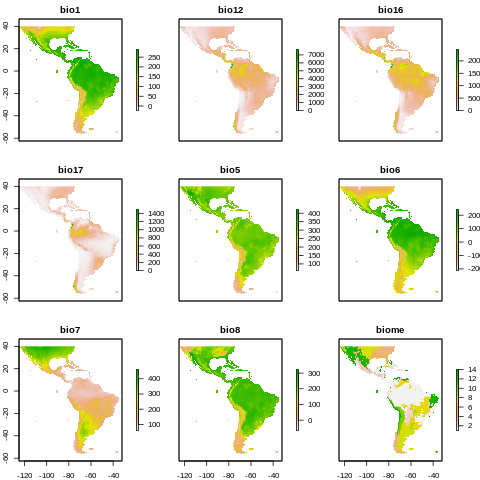

In [ ]:
%%R
# Display the predictor variables in the `predictors` raster stack.
plot(predictors)

### 4.3. Prepare background / pseudo-absence points

Classification algorithms such as Random Forest need examples of both classes: presence (1) and absence (0).

Field surveys generally record presences only, so artificial absence examples must be generated as background points.

In [ ]:
%%R

# set.seed() fixes the "seed" of the random number generator.
# This is crucial for scientific reproducibility: thanks to this command,
# the exact same random coordinates will be generated every time the code
# is run (and for every reader of your paper).
set.seed(0)

# Instead of a hardcoded number, we can generate a number of pseudo-absences
# exactly equal to the number of our presence points (a 1:1 class balance).
n_pres <- nrow(bradypus_coords)
print(paste("Number of presence points:", n_pres))

# Generate a balanced background:
# The randomPoints() function from the dismo package scatters random points across the map.
# 1. The 'predictors' argument (our stack of climate maps) acts as a mask.
#    This ensures that random points will only land on land (where climate
#    data is available) and not in the ocean.
# 2. 'n' is the number of background points we want to generate.
bg <- randomPoints(predictors, n = n_pres)

# At this stage, you can set any number for generating pseudo-absence points,
# but in real-world projects using RF, keep an eye on class balance.

[1] "Number of presence points: 116"


**⚠️ IMPORTANT METHODOLOGICAL DIGRESSION: Pseudo-absences in Random Forest vs. MaxEnt**

The `randomPoints()` command scatters random coordinates across the map. However, depending on the chosen machine learning algorithm, the meaning of these points changes fundamentally:

1. **What is the problem with Random Forest?**
   Random Forest is a binary classifier. It strictly divides the world into two classes: **1 (presence)** and **0 (absence)**. The algorithm does not understand the concept of a "background environment" and treats our generated random points as **True Absences**.
   * **Risk of error:** Since points are scattered randomly across the entire study area, there is a high probability that some will fall into ideal environmental conditions for the species or even overlap with actual occurrence coordinates! The model will receive contradictory signals (under identical conditions, the species is simultaneously "present" and "absent").
   * **Class Imbalance:** If we have 50 occurrence points and generate 500 pseudo-absences, Random Forest will be heavily biased toward "zero" (absence). The model will tend to predict absence simply because there are 10 times more such examples.

2. **Why does MaxEnt work differently?**
   The **MaxEnt** (Maximum Entropy) algorithm, on the other hand, is designed specifically for *Presence-Only* data. It **does not need** absence points. For MaxEnt, random background points are a way to "sample" the available environmental space of the entire study region (Calibration Area). Therefore, for MaxEnt, generating 10,000+ background points is not only normal but necessary.

**💡 Best practices for Random Forest (if no true absences are available):**
* **1:1 Balancing:** It is recommended to generate a number of pseudo-absences comparable to the number of presence points (a ratio of ~1:1 or 1:2) to minimize class imbalance.
* **Ensemble approach (Bootstrap):** In rigorous studies, researchers train dozens of RF models, generating a new random batch of pseudo-absences (equal to the number of occurrence points) each time, and produce the final map by averaging the predictions across all iterations.
* **Geographic filtering:** Exclude the generation of background points in the immediate vicinity of known occurrences (for example, by setting a buffer zone around presence points).

*For more details on typical mistakes in SDMs, read the article: Sillero, N., & Barbosa, A. M. (2021). Common mistakes in ecological niche models. International Journal of Geographical Information Science, 35(2), 213–226. <https://doi.org/10.1080/13658816.2020.1798968>*

## Step 5: Modeling with Random Forest

### 5.1. Prepare the data and train the model

Random Forest can sometimes have problems with categorical raster layers. In this example, that layer is `biome`, so we remove it for reliability.

In [ ]:
%%R
# Prepare the training dataset.

# 1. Remove the categorical `biome` layer to improve Random Forest stability.
# The R `randomForest` implementation can perform poorly with rasters containing many categorical levels.
# `dropLayer()` removes this layer.
predictors_rf <- dropLayer(predictors, "biome")

# 2. Extract climatic raster values at the training coordinates.
# `extract()` retrieves temperature, precipitation, and other values for each point.
# `data.frame()` converts the result into a table with points as rows and climatic variables as columns.
env_train_pres <- data.frame(extract(predictors_rf, train_points)) # Climate at confirmed presence locations.
env_train_bg   <- data.frame(extract(predictors_rf, bg)) # Climate at random background locations.

# 3. Combine the tables vertically with `rbind()`.
# The `rbind()` (row bind) function joins two tables vertically (adds rows to one another).
train_data <- rbind(env_train_pres, env_train_bg)

# 4. Create the target response vector.
# `rep(1, ...)` creates one value for each presence; `rep(0, ...)` does the same for background points.
# `c(...)` combines them into the presence/absence vector `pa`.
pa <- c(rep(1, nrow(env_train_pres)), rep(0, nrow(env_train_bg)))

# IMPORTANT: Convert zeros and ones into categorical factors with `as.factor()`.
# Otherwise Random Forest will interpret them as continuous values and fit a regression model.
# A classification model is required here.
train_data$presence <- as.factor(pa)

# 5. Remove rows containing missing values with `na.omit()`.
# This prevents errors if a point falls outside the raster coverage.
train_data <- na.omit(train_data)

### 5.2. Train the model

In [ ]:
%%R
# Fix the random processes again with `set.seed()`.
# Random Forest builds many random data subsets, so the seed makes the fitted model reproducible.
set.seed(42)

# Train the model. Key arguments:
# 1. Formula `presence ~ .`: predict `presence` from every other column.
# 2. `data=train_data`: use the prepared presence and background table.
# 3. `importance=TRUE`: calculate the importance of each climatic predictor. A crucial parameter for ecologists!
# 4. `ntree=500`: build 500 decision trees, a common balance between accuracy and speed.
rf_model <- randomForest(presence ~ ., data=train_data, importance=TRUE, ntree=500)

# Print the model summary.
# In the output includes the OOB error (Out-of-Bag estimate of error rate) - this is
# an internal estimate of how often the model makes mistakes, as well as the confusion matrix,
# which shows how well classes 0 and 1 are separated.
print(rf_model)


Call:
 randomForest(formula = presence ~ ., data = train_data, importance = TRUE,      ntree = 500) 
               Type of random forest: classification
                     Number of trees: 500
No. of variables tried at each split: 2

        OOB estimate of  error rate: 18.72%
Confusion matrix:
   0  1 class.error
0 92 24   0.2068966
1 14 73   0.1609195


### 5.3. Assess predictor importance

For ecologists, understanding the biology can be more important than simply producing a map: which factors—heat, cold, or precipitation—most strongly limit the species' range?

We obtain variable importance with `importance()`. This function extracts importance metrics for every predictor from the trained model.

1. `MeanDecreaseAccuracy`: Shows how much model accuracy decreases when a climatic factor is removed or disrupted. The HIGHER the value, the MORE IMPORTANT the predictor.

2. `MeanDecreaseGini`: Shows how effectively a variable separates presence (1) from absence/background (0) within the decision trees. Again, a larger value indicates greater importance for the sloth.

In [ ]:
%%R
# This works because `importance=TRUE` was set when the model was trained.
rf_importance <- importance(rf_model)

# Print the importance table.
print(rf_importance)

              0         1 MeanDecreaseAccuracy MeanDecreaseGini
bio1   7.619076 10.319099            13.903272         8.329918
bio12  6.458815 21.873389            20.123608        14.911477
bio16 10.829828 24.837002            25.616300        17.416643
bio17  4.585931 11.265072            12.586779        10.754428
bio5   5.697647 12.884587            14.724006         8.787333
bio6   9.716229 15.103810            19.012060        12.376564
bio7  11.826537 20.227940            22.242515        19.692090
bio8   1.646285  7.512133             7.535731         5.898168


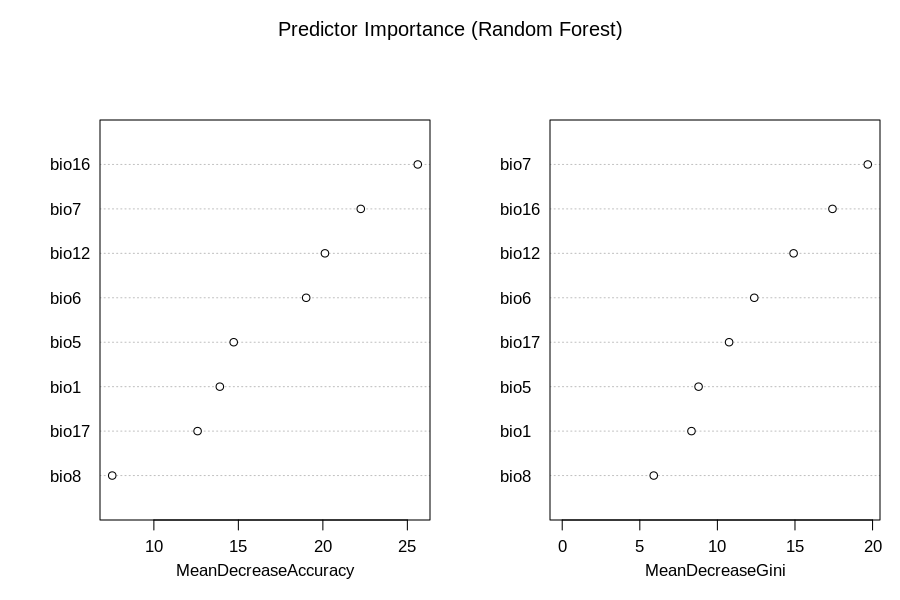

In [ ]:
%%R -w 900 -h 600 -r 100
# -w 1200 (width) and -h 600 (height) set the resulting image size in pixels.
# -r 100 (resolution) sets the resolution (DPI).
# This makes the graphs wide and clear.

# Visualize variable importance.
# `varImpPlot()` is the standard importance plot for `randomForest` models.
# It is more informative than a simple percentage bar chart.
varImpPlot(rf_model, main="Predictor Importance (Random Forest)")

### 5.4. Evaluate model accuracy with AUC — step-by-step

The `evaluate()` function from `dismo` works well with Random Forest. To avoid confusion over data formats, however, we will manually generate predictions at the test points and pass the resulting probabilities to the function.

class          : ModelEvaluation 
n presences    : 29 
n absences     : 116 
AUC            : 0.9867717 
cor            : 0.8471778 
max TPR+TNR at : 0.3479 
[1] "Test AUC (Random Forest): 0.986771700356718"


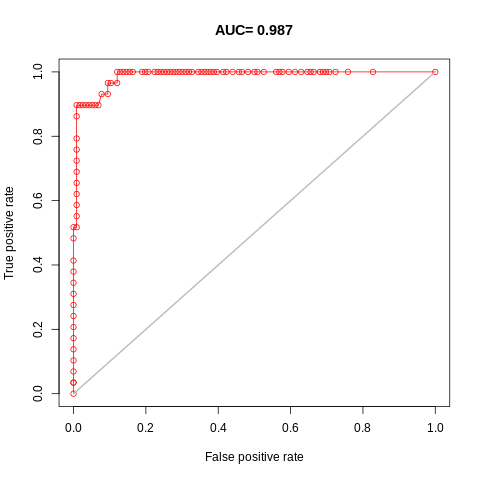

In [ ]:
%%R
# STEP 1: Extract climatic predictor values for the test points.
# `extract()` samples the rasters at the supplied coordinates.
# `data.frame()` converts values into a table; `na.omit()` removes points outside raster coverage.
env_test_pres <- na.omit(data.frame(extract(predictors_rf, test_points))) # Real species-presence points.
env_test_bg <- na.omit(data.frame(extract(predictors_rf, bg)))            # Background or pseudo-absence points.

# STEP 2: Generate probability predictions for the new data.
# Feed our trained model (rf_model) the new climate tables.
# Important: `type="prob"` tells Random Forest to output probabilities, not just a hard class (0 or 1).
# The predict output is a two-column matrix.
# Column 1: absence probability, column 2: presence probability.
# We need the presence probability, so we take the second column using [, 2].
rf_pred_pres <- predict(rf_model, env_test_pres, type="prob")[, 2]
rf_pred_bg <- predict(rf_model, env_test_bg, type="prob")[, 2]

# STEP 3: Calculate model-quality metrics.
# The evaluate() function from the dismo package compares the predicted probabilities
# at presence points (p) with the probabilities at background points (a).
# Based on this, statistics are calculated, including the main metric, AUC.
rf_eval <- evaluate(p=rf_pred_pres, a=rf_pred_bg)

# Print the results.
print(rf_eval)
print(paste("Test AUC (Random Forest):", rf_eval@auc))

# STEP 4: Visualize the result.
# Plot the ROC curve. The more the curve bends toward the upper left,
# the better the model is at distinguishing suitable conditions from unsuitable ones.
plot(rf_eval, 'ROC', main="ROC curve for the test sample")

**Interpreting the model metrics**
- `n presences`: Number of presence points used for evaluation that were not used during training.
- `n absences`: Number of background or pseudo-absence points.
- `AUC`: Area Under the Curve. This metric summarizes model performance as the area under the ROC curve. AUC ranges from 0 to 1; higher values indicate better performance. An AUC of 0.5 indicates no discriminatory ability, while 1.0 represents perfect class separation.
- `cor`: Correlation between model predictions and observed classes, where 1 is presence and 0 is background. For SDMs, values around 0.3–0.5 can be entirely normal.
- `max TPR+TNR`: The optimal classification threshold. The model produces continuous suitability values from 0.0 to 1.0, but researchers often need a binary map showing where the species can or cannot occur. This threshold maximizes the balance between sensitivity (TPR, correctly identified presences) and specificity (TNR, correctly identified background points).

### 5.5. Optional: Select a threshold for a binary map

The model returns probabilities from 0 to 1. Conservation decisions often require a strict boundary: the species is considered present here (1) and absent there (0). To convert the continuous suitability map into a binary map, we must choose a classification threshold.


In [ ]:
%%R

# Calling `threshold()` without specifying a method calculates all available statistical thresholds.
all_thresholds <- threshold(rf_eval)

# Print all available threshold criteria.
print("All available criteria for the threshold:")
print(all_thresholds)

[1] "All available criteria for the threshold:"
            kappa spec_sens no_omission prevalence equal_sens_spec sensitivity
thresholds 0.3479    0.3479      0.2299     0.2019          0.2819      0.2879


**Interpretation of each criterion:**

1. `kappa` — Maximum Cohen's kappa
   - Calculation: Finds the threshold that maximizes Cohen's kappa, which measures how much better the prediction is than chance while accounting for class imbalance.
   - Use: It was common in the past but is now less frequently used in studies. A high threshold makes the model very strict and retains only the most suitable habitat.

2. `spec_sens` — Maximum balance, or Max TPR + TNR
   - Calculation: Finds the point where the sum of sensitivity and specificity is greatest.
   - Use: This is one of the most popular and broadly applicable approaches in ecology and usually produces a balanced binary map.

3. `no_omission` — No omissions, or 0% false negatives
   - Calculation: Selects the highest threshold at which none of the test presence points is excluded. In other words, all known occurrences remain inside the predicted suitable area.
   - Use: Appropriate when missing suitable habitat is especially costly, such as when planning reserves for an endangered species or predicting a dangerous invasive plant. It is conservative and therefore usually produces a broad range.

4. `prevalence` — Preserve prevalence
   - Calculation: Chooses a threshold so that the proportion of suitable map area matches the proportion of presence points relative to background points.
   - Use: Rarely appropriate for workflows unless true prevalence is known. Because the background points here are generated artificially, this threshold has little biological meaning.

5. `equal_sens_spec` — Equal sensitivity and specificity
   - Calculation: Selects the threshold at which the percentage of correctly predicted presences equals the percentage of correctly rejected background points.
   - Use: An alternative to `spec_sens`. It provides strict mathematical parity between the two error types, but may produce a somewhat narrower predicted range.

6. `sensitivity` — Fixed sensitivity
   - Calculation: In `dismo`, this criterion normally finds the threshold at which 90% of observed presences are predicted correctly, while 10% are treated as possible errors or outliers.
   - Use: A useful compromise when occurrence data may contain mistakes. Unlike `no_omission`, it prevents one erroneous point from greatly inflating the predicted range.

### 5.6. Prediction map

The `raster` package supports Random Forest models directly. We apply the trained model to the predictor stack with `predict()`.

What happens here:
1. `predictors_rf` is the stack of climatic rasters. `predict()` reads predictor values pixel by pixel and passes them to the model.
2. `rf_model` is the trained Random Forest model.
3. `type="prob"` requests probabilities from 0 to 1 rather than hard presence/absence classes.
4. `index=2` is CRITICAL. For classification, Random Forest returns two probability columns: the first for class `0` (absence) and the second for class `1` (presence). The `raster` package would normally use the first output layer. Setting `index=2` explicitly stores the probability of species PRESENCE.

In [ ]:
%%R
# Create the habitat-suitability raster as a spatial prediction.
rf_suitability_map <- predict(predictors_rf, rf_model, type="prob", index=2)

In [ ]:
%%R
# Create a binary raster using the `max TPR+TNR` threshold.

# 1. Extract the numeric threshold value by selecting `spec_sens`.
rf_threshold <- threshold(rf_eval, 'spec_sens')

# 2. Create a binary raster with raster algebra.
rf_binary_map <- rf_suitability_map >= rf_threshold

#### Visualize and compare the results

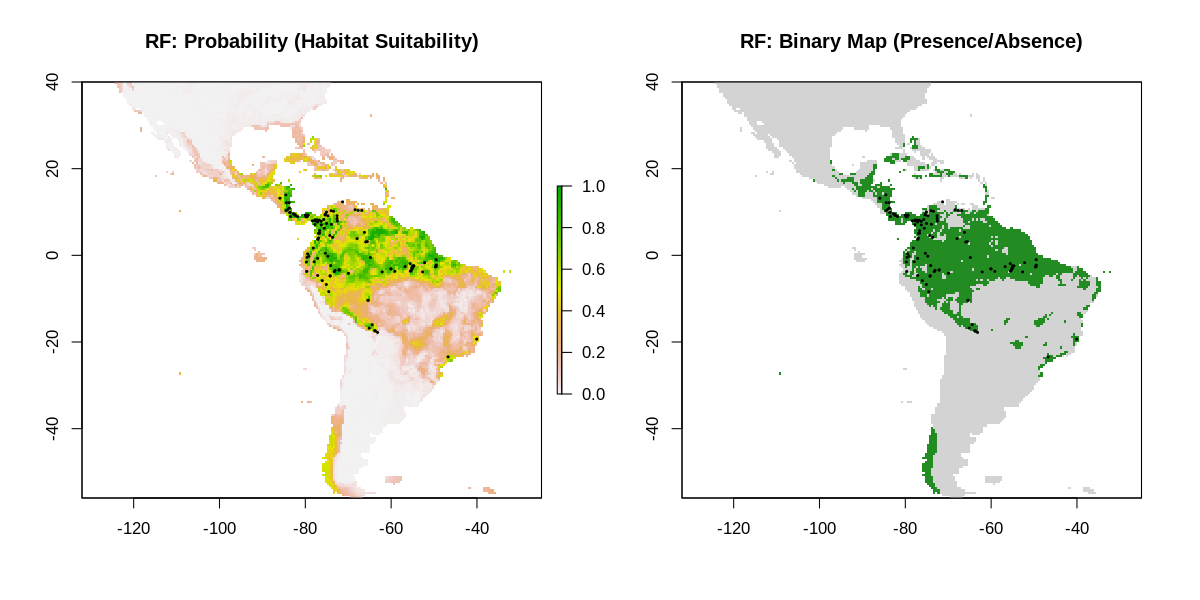

In [ ]:
%%R -w 1200 -h 600 -r 100
# Colab magic settings: `-w` and `-h` set image width and height; `-r` sets resolution in DPI.
# These settings produce a wide, clear figure containing two maps.

# `par(mfrow=c(1,2))` divides the R graphics device into one row and two columns.
# The next two plots are drawn side by side.
par(mfrow = c(1, 2))

# PLOT 1: Continuous probability map on the left.
plot(rf_suitability_map, main="RF: Probability (Habitat Suitability)")
# `points()` overlays occurrence coordinates; `pch=20` selects filled circles and `cex=0.4` sets their size.
points(bradypus_coords, pch=20, cex=0.4, col="black")

# PLOT 2: Binary range map on the right.
# A two-color palette is used because values are only 0 and 1.
# 0 means unsuitable and 1 means suitable.
# Hide the numeric legend because the classes are self-explanatory.
plot(rf_binary_map,
     main="RF: Binary Map (Presence/Absence)",
     col=c("lightgrey", "forestgreen"),
     legend=FALSE)
points(bradypus_coords, pch=20, cex=0.4, col="black")

# IMPORTANT: Restore the standard one-plot layout.
# Otherwise later plots will remain squeezed into one of the two columns.
par(mfrow = c(1, 1))

### 5.7. Export the modeling results to GeoTIFF

#### Create GeoTIFF rasters

The `writeRaster()` function from the `raster` package saves the maps as files.

Key arguments:
- `filename`: Name of the output file, including the `.tif` extension.
- `format="GTiff"`: GeoTIFF is a global GIS standard. It is essentially an image with geographic coordinates embedded for every pixel.
- `overwrite=TRUE`: Overwrite the file when the cell is run again, avoiding an error that the file already exists.

In [ ]:
%%R
# 1. Export the continuous probability map with values from 0.0 to 1.0.
writeRaster(rf_suitability_map,
            filename="rf_probability_map.tif",
            format="GTiff",
            overwrite=TRUE)

# 2. Export the binary map with values 0 and 1, classified using the `max TPR+TNR` threshold.
writeRaster(rf_binary_map,
            filename="rf_binary_map.tif",
            format="GTiff",
            overwrite=TRUE)

print("Random Forest maps successfully saved to GeoTIFF!")

[1] "Random Forest maps successfully saved to GeoTIFF!"


#### Download the results

The files are stored in Colab's temporary storage, in the `/content` directory.

To download them manually, click the folder icon in the left-hand menu, locate the `.tif` files, click the three dots beside a file, and select **Download**.

You can also use `files.download()`. It searches for the named file in Colab's virtual storage and opens the browser download dialog automatically.

In [ ]:
print("Preparing to download the probability map...")
files.download('rf_probability_map.tif')

print("Preparing to download the binary map...")
files.download('rf_binary_map.tif')

Preparing to download the probability map...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Preparing to download the binary map...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

If you find this guide helpful,
Let's connect on LinkedIn <https://www.linkedin.com/in/anton-biatov/>!

And follow my blog on Medium <https://medium.com/@anton.biatov>